In [1]:
import requests


raw_data_url_base = "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/"


image_filenames = [
    "lena.jpg",
    "smarties.png",
    "baboon.jpg"
]


for filename in image_filenames:
    file_url = raw_data_url_base + filename
    response = requests.get(file_url)

    if response.status_code == 200:
        with open(filename, 'wb') as f:
            f.write(response.content)
        print(f"Downloaded {filename}")
    else:
        print(f"Failed to download {filename}")

Downloaded lena.jpg
Downloaded smarties.png
Downloaded baboon.jpg


In [2]:
import cv2
import os

image_paths = [
    "lena.jpg",
    "smarties.png",
    "baboon.jpg"
]

for path in image_paths:
    img = cv2.imread(path)

    if img is not None:
        print(f"Image: {path}")
        print("Shape (H x W x C):", img.shape)
        print()
    else:
        print(f"Could not load {path}")

Image: lena.jpg
Shape (H x W x C): (512, 512, 3)

Image: smarties.png
Shape (H x W x C): (356, 413, 3)

Image: baboon.jpg
Shape (H x W x C): (512, 512, 3)



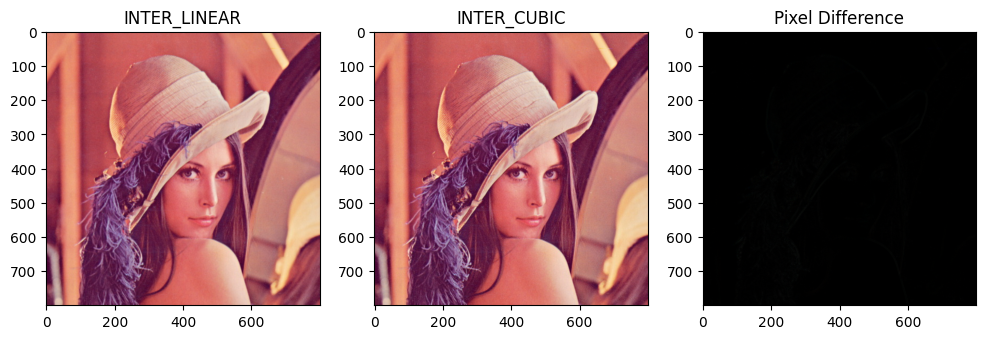

In [3]:
import matplotlib.pyplot as plt

img = cv2.imread("lena.jpg")

linear = cv2.resize(img, (800, 800), interpolation=cv2.INTER_LINEAR)

cubic = cv2.resize(img, (800, 800), interpolation=cv2.INTER_CUBIC)

difference = cv2.absdiff(linear, cubic)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(cv2.cvtColor(linear, cv2.COLOR_BGR2RGB))
plt.title("INTER_LINEAR")

plt.subplot(1,3,2)
plt.imshow(cv2.cvtColor(cubic, cv2.COLOR_BGR2RGB))
plt.title("INTER_CUBIC")

plt.subplot(1,3,3)
plt.imshow(cv2.cvtColor(difference, cv2.COLOR_BGR2RGB))
plt.title("Pixel Difference")

plt.show()

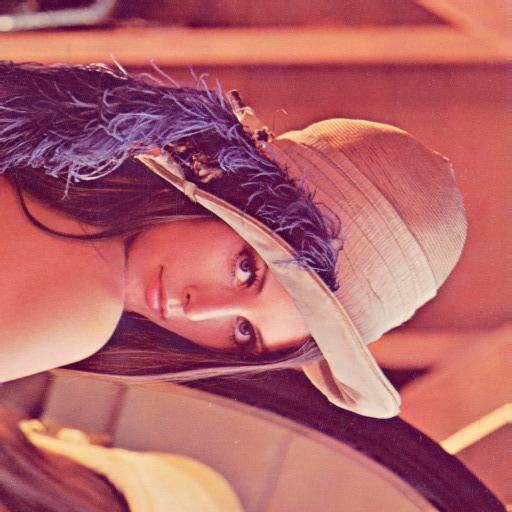

In [6]:
import numpy as np
from google.colab.patches import cv2_imshow

img = cv2.imread("lena.jpg")

# 90 degree rotation
rotated_90 = cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)

cv2_imshow(rotated_90)

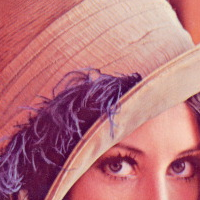

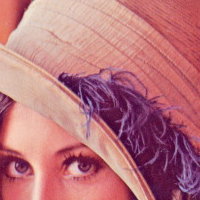

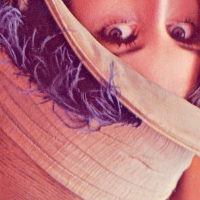

In [7]:
img = cv2.imread("lena.jpg")

# ROI Crop
roi = img[100:300, 150:350]

# Horizontal Flip
horizontal_flip = cv2.flip(roi, 1)

# Vertical Flip
vertical_flip = cv2.flip(roi, 0)

cv2_imshow(roi)
cv2_imshow(horizontal_flip)
cv2_imshow(vertical_flip)

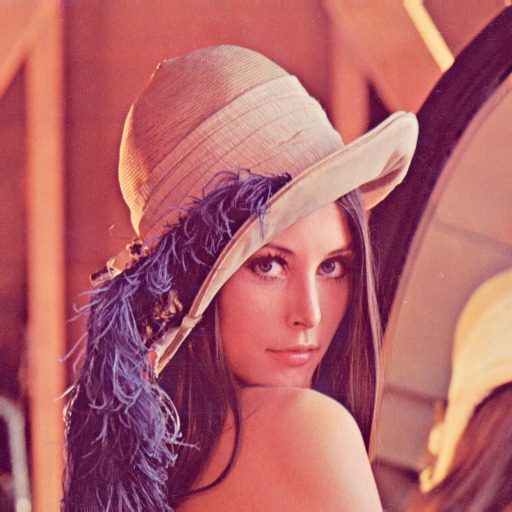

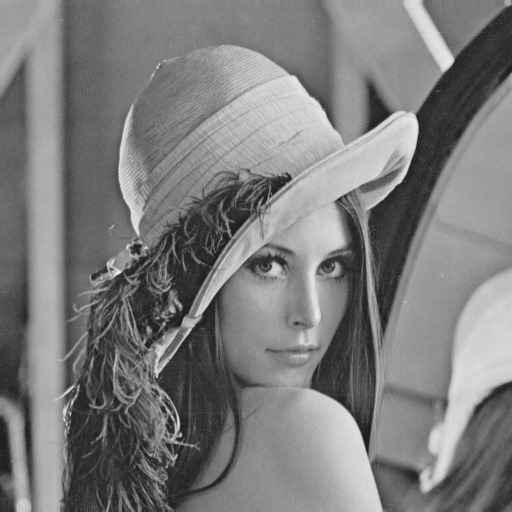

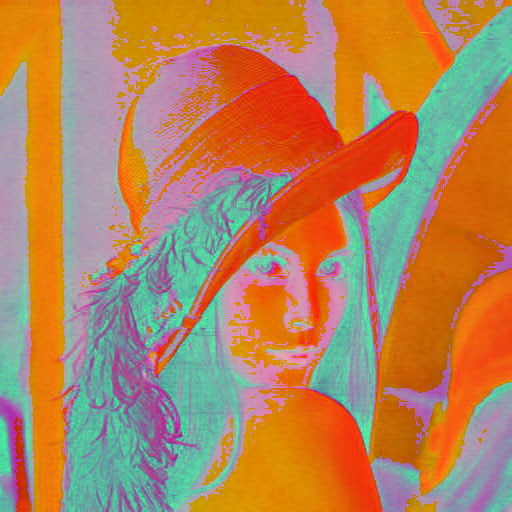

In [8]:
img = cv2.imread("lena.jpg")

# Grayscale Conversion
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# HSV Conversion
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

cv2_imshow(img)
cv2_imshow(gray)
cv2_imshow(hsv)

**************************************

# **Mini Project**

In [14]:
# loadind raw images from github

!wget https://raw.githubusercontent.com/opencv/opencv/master/samples/data/lena.jpg
!wget https://raw.githubusercontent.com/opencv/opencv/master/samples/data/baboon.jpg
!wget https://raw.githubusercontent.com/opencv/opencv/master/samples/data/fruits.jpg
!wget https://raw.githubusercontent.com/opencv/opencv/master/samples/data/home.jpg
!wget https://raw.githubusercontent.com/opencv/opencv/master/samples/data/smarties.png

--2026-06-06 03:24:42--  https://raw.githubusercontent.com/opencv/opencv/master/samples/data/lena.jpg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.111.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 91814 (90K) [image/jpeg]
Saving to: ‘lena.jpg’

lena.jpg            100%[===================>]  89.66K  --.-KB/s    in 0.008s  

2026-06-06 03:24:42 (10.6 MB/s) - ‘lena.jpg’ saved [91814/91814]

--2026-06-06 03:24:42--  https://raw.githubusercontent.com/opencv/opencv/master/samples/data/baboon.jpg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.111.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 179920 (176K) [image/jpeg]
Saving to: ‘

In [15]:
import os

print(os.listdir())

['.config', 'smarties.png.1', 'home.jpg', 'smarties.png', 'medical_scans', 'baboon.jpg', 'fruits.jpg', 'lena.jpg', 'sample_data']


In [16]:
import cv2

img = cv2.imread("lena.jpg")

print(img.shape)

(512, 512, 3)


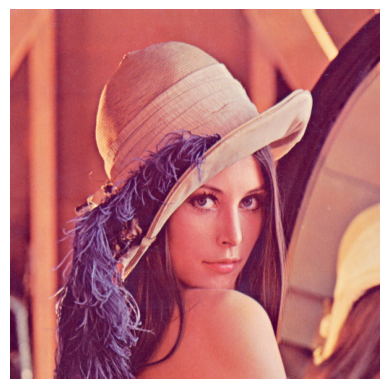

In [17]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("lena.jpg")

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.axis("off")
plt.show()

In [18]:
import os

os.makedirs("medical_scans", exist_ok=True)

In [19]:
import shutil

shutil.move("lena.jpg", "medical_scans/lena.jpg")
shutil.move("baboon.jpg", "medical_scans/baboon.jpg")
shutil.move("fruits.jpg", "medical_scans/fruits.jpg")

'medical_scans/fruits.jpg'

In [20]:
input_folder = "medical_scans"
output_folder = "normalized_scans"

os.makedirs(output_folder, exist_ok=True)

TARGET_SIZE = (512, 512)

for filename in os.listdir(input_folder):

    if filename.endswith((".jpg", ".png", ".jpeg")):

        path = os.path.join(input_folder, filename)

        img = cv2.imread(path)

        if img is None:
            continue

        # Resize
        resized = cv2.resize(
            img,
            TARGET_SIZE,
            interpolation=cv2.INTER_AREA
        )

        # Convert to Grayscale
        gray = cv2.cvtColor(
            resized,
            cv2.COLOR_BGR2GRAY
        )

        output_path = os.path.join(
            output_folder,
            filename
        )

        cv2.imwrite(output_path, gray)

print("Normalization Completed")

Normalization Completed
